Scaling, Encoding & Class Imbalance Handling

Load Data

In [2]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("../data/raw/processed/fraud_features.csv")


Train-Test Split

In [3]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Scaling

In [4]:
scaler = StandardScaler()

num_cols = ["purchase_value", "age", "time_since_signup", "txn_count"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

One-Hot Encoding

In [12]:
drop_cols = [
    "user_id",
    "device_id",
    "ip_address"
]

X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

In [13]:

for df in [X_train, X_test]:
    df["signup_time"] = pd.to_datetime(df["signup_time"])
    df["purchase_time"] = pd.to_datetime(df["purchase_time"])

    df["signup_hour"] = df["signup_time"].dt.hour
    df["signup_day"] = df["signup_time"].dt.dayofweek

    df["purchase_hour"] = df["purchase_time"].dt.hour
    df["purchase_day"] = df["purchase_time"].dt.dayofweek

    df["time_diff"] = (df["purchase_time"] - df["signup_time"]).dt.total_seconds()

# then drop raw timestamps
X_train = X_train.drop(columns=["signup_time", "purchase_time"])
X_test = X_test.drop(columns=["signup_time", "purchase_time"])

In [14]:
cat_cols = ["browser", "source", "sex"]

X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)

In [15]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

SMOTE

In [16]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Before vs After Imbalance

In [17]:
print("Before:\n", y_train.value_counts())
print("\nAfter:\n", y_train_res.value_counts())

Before:
 class
0    109568
1     11321
Name: count, dtype: int64

After:
 class
0    109568
1    109568
Name: count, dtype: int64


### Why SMOTE

Both Fraud_Data.csv and creditcard.csv are highly imbalanced datasets, where fraudulent transactions represent only a small fraction of all observations.

Training directly on such data may bias the model toward the majority class, leading to poor fraud detection performance.

SMOTE (Synthetic Minority Oversampling Technique) was selected because it:
- Generates synthetic examples of the minority class.
- Reduces bias toward the majority class.
- Preserves all available legitimate transactions.
- Is widely used for fraud detection problems.

To prevent data leakage, SMOTE is applied only to the training set after the train-test split.

Visualize Before Resampling

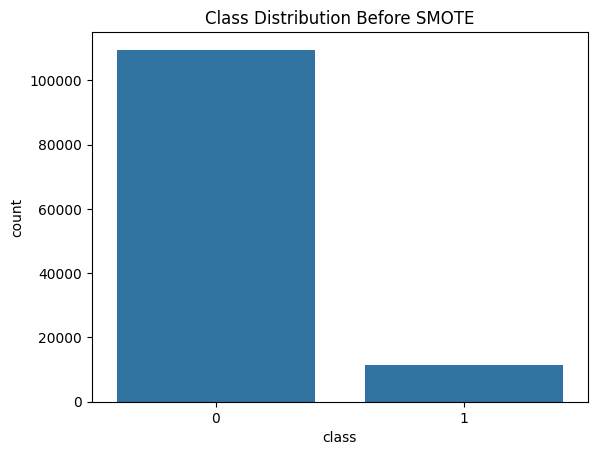

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")
plt.show()

Visualize After Resampling

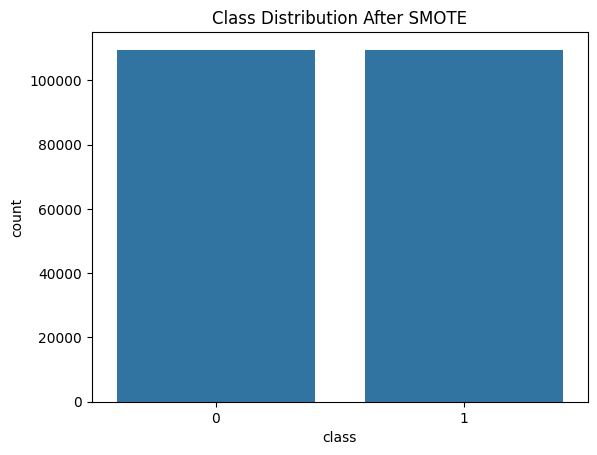

In [26]:
sns.countplot(x=y_train_res)
plt.title("Class Distribution After SMOTE")
plt.show()

In [27]:
before = y_train.value_counts().rename("Before_SMOTE")
after = y_train_res.value_counts().rename("After_SMOTE")

comparison = pd.concat([before, after], axis=1)
comparison

,Before_SMOTE,After_SMOTE
class,,
0,109568,109568
1,11321,109568


### Resampling Outcome

SMOTE was applied exclusively to the training data after stratified train-test splitting to avoid information leakage.

The minority fraud class increased from approximately 6% of the training data to 50%, creating a balanced dataset for model training while leaving the test set untouched for unbiased evaluation.